In [1]:
import sys
sys.path.insert(0, '.')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import os

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 30)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.2f}'.format)

# Resolve DATA_DIR relative to this notebook's location
NOTEBOOK_DIR = Path(os.path.dirname(os.path.abspath('__file__')))
# Try both possible locations (running from analysis/ or from project root)
if (NOTEBOOK_DIR / 'data').exists():
    DATA_DIR = NOTEBOOK_DIR / 'data'
elif (NOTEBOOK_DIR / '../data').exists():
    DATA_DIR = NOTEBOOK_DIR / '../data'
else:
    DATA_DIR = Path('data')

print(f"Data directory: {DATA_DIR.resolve()}")

Data directory: /Users/koristuvac/DEV/optiflow/data


# 01 — Data Exploration & Quality Assessment

**Challenge 002: Redesign de Suporte — OptiFlow**

This notebook is our first pass through the raw data. Before designing anything, we need to understand what we have.

**Datasets:**
- **Dataset 1:** Customer Support Tickets (~30K) — rich: channels, priorities, time metrics, satisfaction
- **Dataset 2:** IT Service Tickets (~48K) — text + category labels (classification training)

**Questions to answer:**
1. What does the data look like? (shape, types, nulls, distributions)
2. What channels, priorities, and ticket types exist?
3. How long does resolution take? Where is variance highest?
4. What drives customer satisfaction (or dissatisfaction)?
5. What's the data quality — can we trust these numbers?

## Metodologia: Por que explorar os dados primeiro?

Estamos diante de um **desafio operacional** — redesenhar o processo de suporte ao cliente de uma empresa de tecnologia. Antes de propor qualquer automação ou mudança, precisamos **entender o processo atual (as-is)**.

O problema: **não temos um diagrama de processo pronto**. O que temos são **dados brutos de tickets**. Nossa missão nesta etapa é encontrar **pistas nos dados** que nos ajudem a reconstruir:

1. **Quais são as etapas do processo?** — Os campos categóricos (canal, tipo, status, prioridade) revelam as classificações e rotas que o processo usa
2. **Quanto tempo cada etapa leva?** — FRT (tempo até primeira resposta) e TTR (tempo até resolução) são nossos indicadores de velocidade operacional
3. **Onde o processo falha?** — A satisfação do cliente (CSAT) é nosso indicador de resultado

### Abordagem sistemática:
- **Passo 1:** Abrir os dois datasets, ver as primeiras linhas, entender o que cada coluna representa
- **Passo 2:** Classificar cada variável (categórica, quantitativa, texto livre, identificador)
- **Passo 3:** Para variáveis categóricas — listar todos os valores possíveis (são as "rotas" do processo)
- **Passo 4:** Para variáveis quantitativas — análise estatística (média, mediana, desvio, distribuição)
- **Passo 5:** Para texto livre — examinar amostras e decidir como tratar (classificação LLM virá depois)

### Visão futura:
Após esta exploração no Jupyter, vamos construir o **OptiFlow** — um sistema guiado que replica este método de análise automaticamente a partir de qualquer dataset de operações. O notebook documenta o raciocínio; o sistema o transforma em ferramenta reutilizável.

---
## Passo 1: Carregar e visualizar os dados brutos

Vamos abrir os dois datasets e ver as primeiras 5 linhas de cada um — sem transformações, exatamente como vieram.

## 1. Load & Inspect — Dataset 1 (Support Tickets)

In [2]:
df1 = pd.read_csv(DATA_DIR / 'customer_support_tickets.csv')
print(f"Dataset 1 — Customer Support Tickets")
print(f"Linhas: {df1.shape[0]:,} | Colunas: {df1.shape[1]}")
print(f"\nColunas: {list(df1.columns)}")
df1.head(5)

Dataset 1 — Customer Support Tickets
Linhas: 8,469 | Colunas: 17

Colunas: ['Ticket ID', 'Customer Name', 'Customer Email', 'Customer Age', 'Customer Gender', 'Product Purchased', 'Date of Purchase', 'Ticket Type', 'Ticket Subject', 'Ticket Description', 'Ticket Status', 'Resolution', 'Ticket Priority', 'Ticket Channel', 'First Response Time', 'Time to Resolution', 'Customer Satisfaction Rating']


,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:36,NaN,NaN
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:38,NaN,NaN
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.00
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,I'm having an issue with the {product_purchase...,Closed,Try capital clearly never color toward story.,Low,Social media,2023-06-01 07:29:40,2023-06-01 01:57:40,3.00
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,Closed,West decision evidence bit.,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,1.00


In [3]:
df2 = pd.read_csv(DATA_DIR / 'it_service_tickets.csv')
print(f"Dataset 2 — IT Service Tickets")
print(f"Linhas: {df2.shape[0]:,} | Colunas: {df2.shape[1]}")
print(f"\nColunas: {list(df2.columns)}")
df2.head(5)

Dataset 2 — IT Service Tickets
Linhas: 47,837 | Colunas: 2

Colunas: ['Document', 'Topic_group']


,Document,Topic_group
0,connection with icon icon dear please setup ic...,Hardware
1,work experience user work experience user hi w...,Access
2,requesting for meeting requesting meeting hi p...,Hardware
3,reset passwords for external accounts re expir...,Access
4,mail verification warning hi has got attached ...,Miscellaneous


---
## Passo 2: Classificação de cada variável

Para cada coluna, precisamos identificar seu tipo:
- **Identificador** — ID único, não serve para análise estatística
- **Categórica** — valores finitos e repetidos (canais, tipos, status) → revelam as "rotas" do processo
- **Quantitativa** — valores numéricos mensuráveis (tempos, ratings) → revelam performance
- **Texto livre** — descrições únicas por ticket → precisam de NLP/LLM para classificar
- **Temporal** — tempos expressos como texto ("5 hours", "2 days") → precisam de parsing

### Dataset 1 — Classificação das variáveis

In [4]:
# Classificação automática de cada variável do Dataset 1
print("=" * 80)
print("DATASET 1 — CLASSIFICAÇÃO DE VARIÁVEIS")
print("=" * 80)

for col in df1.columns:
    n_unique = df1[col].nunique()
    dtype = df1[col].dtype
    nulls = df1[col].isnull().sum()
    sample = df1[col].dropna().iloc[0] if df1[col].notna().any() else None
    
    # Classificar tipo
    if n_unique == len(df1) or n_unique > len(df1) * 0.9:
        if dtype == 'object':
            var_type = "🔤 TEXTO LIVRE / IDENTIFICADOR"
        else:
            var_type = "🔢 QUANTITATIVA (alta cardinalidade)"
    elif dtype in ['int64', 'float64'] and n_unique <= 20:
        var_type = "📊 CATEGÓRICA (numérica ordinal)"
    elif dtype in ['int64', 'float64']:
        var_type = "🔢 QUANTITATIVA"
    elif dtype == 'object' and n_unique <= 50:
        var_type = "📊 CATEGÓRICA"
    else:
        var_type = "🔤 TEXTO LIVRE"
    
    print(f"\n{'─' * 60}")
    print(f"📌 {col}")
    print(f"   Tipo: {var_type}")
    print(f"   dtype: {dtype} | Únicos: {n_unique:,} | Nulos: {nulls} ({nulls/len(df1)*100:.1f}%)")
    print(f"   Exemplo: {str(sample)[:100]}")

DATASET 1 — CLASSIFICAÇÃO DE VARIÁVEIS

────────────────────────────────────────────────────────────
📌 Ticket ID
   Tipo: 🔢 QUANTITATIVA (alta cardinalidade)
   dtype: int64 | Únicos: 8,469 | Nulos: 0 (0.0%)
   Exemplo: 1

────────────────────────────────────────────────────────────
📌 Customer Name
   Tipo: 🔤 TEXTO LIVRE / IDENTIFICADOR
   dtype: object | Únicos: 8,028 | Nulos: 0 (0.0%)
   Exemplo: Marisa Obrien

────────────────────────────────────────────────────────────
📌 Customer Email
   Tipo: 🔤 TEXTO LIVRE / IDENTIFICADOR
   dtype: object | Únicos: 8,320 | Nulos: 0 (0.0%)
   Exemplo: carrollallison@example.com

────────────────────────────────────────────────────────────
📌 Customer Age
   Tipo: 🔢 QUANTITATIVA
   dtype: int64 | Únicos: 53 | Nulos: 0 (0.0%)
   Exemplo: 32

────────────────────────────────────────────────────────────
📌 Customer Gender
   Tipo: 📊 CATEGÓRICA
   dtype: object | Únicos: 3 | Nulos: 0 (0.0%)
   Exemplo: Other

─────────────────────────────────────────────

---
## Passo 3: Variáveis categóricas — todos os valores possíveis

Cada valor categórico é uma **rota possível no processo**. Se um ticket pode ser "Email" ou "Chat", isso significa que existem pelo menos 2 caminhos de entrada. Se o status pode ser "Open", "Closed" ou "Pending", são 3 estados no fluxo.

Listar esses valores é **mapear o vocabulário do processo**.

In [5]:
# Dataset 1 — Listar todos os valores de variáveis categóricas (até 20 valores)
print("=" * 80)
print("DATASET 1 — VALORES DAS VARIÁVEIS CATEGÓRICAS")
print("=" * 80)

for col in df1.columns:
    n_unique = df1[col].nunique()
    dtype = df1[col].dtype
    
    # Incluir categóricas: object com <= 50 únicos OU numéricas com <= 20 únicos
    is_categorical = (dtype == 'object' and n_unique <= 50) or (dtype in ['int64', 'float64'] and n_unique <= 20)
    
    if is_categorical:
        print(f"\n{'─' * 60}")
        print(f"📊 {col} ({n_unique} valores)")
        vc = df1[col].value_counts()
        if len(vc) > 20:
            print(f"   (mostrando top 20 de {len(vc)})")
            vc = vc.head(20)
        for val, count in vc.items():
            pct = count / len(df1) * 100
            print(f"   • {val}: {count:,} ({pct:.1f}%)")

DATASET 1 — VALORES DAS VARIÁVEIS CATEGÓRICAS

────────────────────────────────────────────────────────────
📊 Customer Gender (3 valores)
   • Male: 2,896 (34.2%)
   • Female: 2,887 (34.1%)
   • Other: 2,686 (31.7%)

────────────────────────────────────────────────────────────
📊 Product Purchased (42 valores)
   (mostrando top 20 de 42)
   • Canon EOS: 240 (2.8%)
   • GoPro Hero: 228 (2.7%)
   • Nest Thermostat: 225 (2.7%)
   • Philips Hue Lights: 221 (2.6%)
   • Amazon Echo: 221 (2.6%)
   • LG Smart TV: 219 (2.6%)
   • Sony Xperia: 217 (2.6%)
   • Roomba Robot Vacuum: 216 (2.6%)
   • Apple AirPods: 213 (2.5%)
   • LG OLED: 213 (2.5%)
   • iPhone: 212 (2.5%)
   • Sony 4K HDR TV: 210 (2.5%)
   • Garmin Forerunner: 208 (2.5%)
   • LG Washing Machine: 208 (2.5%)
   • Canon DSLR Camera: 206 (2.4%)
   • Nikon D: 204 (2.4%)
   • Nintendo Switch Pro Controller: 203 (2.4%)
   • Google Pixel: 203 (2.4%)
   • Fitbit Charge: 202 (2.4%)
   • Sony PlayStation: 202 (2.4%)

──────────────────────────

---
## Passo 4: Variáveis quantitativas — análise estatística

Para as variáveis numéricas, precisamos entender a distribuição: média, mediana, desvio padrão, mínimo, máximo, quartis. Isso revela se os tempos de resposta são consistentes ou se há grande variância (sinal de processo inconsistente).

In [6]:
# Dataset 1 — Análise estatística das variáveis quantitativas
# Nota: FRT e TTR são strings ("5 hours", "2 days") — precisam de parsing primeiro

# Variáveis numéricas nativas
num_cols = df1.select_dtypes(include=['int64', 'float64']).columns.tolist()
print("=" * 80)
print("DATASET 1 — ANÁLISE ESTATÍSTICA (VARIÁVEIS QUANTITATIVAS)")
print("=" * 80)

print(f"\nVariáveis numéricas encontradas: {num_cols}")
print()
df1[num_cols].describe().T.round(2)

DATASET 1 — ANÁLISE ESTATÍSTICA (VARIÁVEIS QUANTITATIVAS)

Variáveis numéricas encontradas: ['Ticket ID', 'Customer Age', 'Customer Satisfaction Rating']



,count,mean,std,min,25%,50%,75%,max
Ticket ID,8469.00,4235.00,2444.93,1.00,2118.00,4235.00,6352.00,8469.00
Customer Age,8469.00,44.03,15.30,18.00,31.00,44.00,57.00,70.00
Customer Satisfaction Rating,2769.00,2.99,1.41,1.00,2.00,3.00,4.00,5.00


### Variáveis temporais (FRT e TTR)

First Response Time e Time to Resolution estão armazenados como texto ("5 hours", "2 days"). Precisamos converter para horas antes de analisar. Essas são as **variáveis mais importantes para o diagnóstico operacional** — medem a velocidade do processo.

In [7]:
# Amostras dos campos de tempo (antes do parsing)
print("Amostras de First Response Time:")
print(df1['First Response Time'].dropna().head(10).tolist())
print(f"\nValores únicos de FRT: {df1['First Response Time'].nunique()}")
print(f"\nAmostras de Time to Resolution:")
print(df1['Time to Resolution'].dropna().head(10).tolist())
print(f"\nValores únicos de TTR: {df1['Time to Resolution'].nunique()}")

Amostras de First Response Time:
['2023-06-01 12:15:36', '2023-06-01 16:45:38', '2023-06-01 11:14:38', '2023-06-01 07:29:40', '2023-06-01 00:12:42', '2023-06-01 10:32:47', '2023-06-01 09:25:48', '2023-06-01 17:46:49', '2023-06-01 12:05:51', '2023-06-01 19:03:53']

Valores únicos de FRT: 5470

Amostras de Time to Resolution:
['2023-06-01 18:05:38', '2023-06-01 01:57:40', '2023-06-01 19:53:42', '2023-05-31 23:51:49', '2023-06-01 09:27:51', '2023-05-31 23:08:55', '2023-06-01 15:58:59', '2023-06-01 20:29:04', '2023-06-01 06:03:17', '2023-06-01 18:23:17']

Valores únicos de TTR: 2728


---
## Passo 5: Variáveis de texto livre — amostras para decisão

Campos de texto livre (Ticket Subject, Ticket Description, Resolution) contêm informação rica mas não-estruturada. Cada entrada é praticamente única. Precisamos decidir como tratar:
- Classificação por LLM?
- Extração de palavras-chave?
- Análise de sentimento?

**Antes de decidir, vamos ver amostras reais para avaliar o conteúdo.**

In [8]:
# Amostras de texto livre — Dataset 1
text_cols = ['Ticket Subject', 'Ticket Description', 'Resolution']

for col in text_cols:
    print(f"\n{'=' * 80}")
    print(f"📝 {col} — {df1[col].nunique():,} valores únicos de {len(df1):,} linhas")
    print(f"   Comprimento médio: {df1[col].dropna().str.len().mean():.0f} caracteres")
    print(f"{'=' * 80}")
    for i, val in enumerate(df1[col].dropna().head(3)):
        print(f"\n   Amostra {i+1}: {val[:300]}{'...' if len(str(val)) > 300 else ''}")
    print()


📝 Ticket Subject — 16 valores únicos de 8,469 linhas
   Comprimento médio: 16 caracteres

   Amostra 1: Product setup

   Amostra 2: Peripheral compatibility

   Amostra 3: Network problem


📝 Ticket Description — 8,077 valores únicos de 8,469 linhas
   Comprimento médio: 290 caracteres

   Amostra 1: I'm having an issue with the {product_purchased}. Please assist.

Your billing zip code is: 71701.

We appreciate that you have requested a website address.

Please double check your email address. I've tried troubleshooting steps mentioned in the user manual, but the issue persists.

   Amostra 2: I'm having an issue with the {product_purchased}. Please assist.

If you need to change an existing product.

I'm having an issue with the {product_purchased}. Please assist.

If The issue I'm facing is intermittent. Sometimes it works fine, but other times it acts up unexpectedly.

   Amostra 3: I'm facing a problem with my {product_purchased}. The {product_purchased} is not turning on. It wa

---
### Dataset 2 — Classificação das variáveis

O Dataset 2 é mais simples: apenas texto do ticket + categoria. Serve como benchmark para classificação.

In [9]:
# Dataset 2 — Classificação de variáveis
print("=" * 80)
print("DATASET 2 — CLASSIFICAÇÃO DE VARIÁVEIS")
print("=" * 80)

for col in df2.columns:
    n_unique = df2[col].nunique()
    dtype = df2[col].dtype
    nulls = df2[col].isnull().sum()
    sample = df2[col].dropna().iloc[0] if df2[col].notna().any() else None
    
    if n_unique <= 20:
        var_type = "📊 CATEGÓRICA"
    elif dtype == 'object' and n_unique > 50:
        var_type = "🔤 TEXTO LIVRE"
    else:
        var_type = "🔢 QUANTITATIVA"
    
    print(f"\n{'─' * 60}")
    print(f"📌 {col}")
    print(f"   Tipo: {var_type}")
    print(f"   dtype: {dtype} | Únicos: {n_unique:,} | Nulos: {nulls}")
    
    if n_unique <= 20:
        print(f"\n   Valores:")
        for val, count in df2[col].value_counts().items():
            pct = count / len(df2) * 100
            print(f"   • {val}: {count:,} ({pct:.1f}%)")
    else:
        print(f"   Exemplo: {str(sample)[:120]}")

DATASET 2 — CLASSIFICAÇÃO DE VARIÁVEIS

────────────────────────────────────────────────────────────
📌 Document
   Tipo: 🔤 TEXTO LIVRE
   dtype: object | Únicos: 47,837 | Nulos: 0
   Exemplo: connection with icon icon dear please setup icon per icon engineers please let other details needed thanks lead

────────────────────────────────────────────────────────────
📌 Topic_group
   Tipo: 📊 CATEGÓRICA
   dtype: object | Únicos: 8 | Nulos: 0

   Valores:
   • Hardware: 13,617 (28.5%)
   • HR Support: 10,915 (22.8%)
   • Access: 7,125 (14.9%)
   • Miscellaneous: 7,060 (14.8%)
   • Storage: 2,777 (5.8%)
   • Purchase: 2,464 (5.2%)
   • Internal Project: 2,119 (4.4%)
   • Administrative rights: 1,760 (3.7%)


In [10]:
df1.dtypes

Ticket ID                         int64
Customer Name                    object
Customer Email                   object
Customer Age                      int64
Customer Gender                  object
Product Purchased                object
Date of Purchase                 object
Ticket Type                      object
Ticket Subject                   object
Ticket Description               object
Ticket Status                    object
Resolution                       object
Ticket Priority                  object
Ticket Channel                   object
First Response Time              object
Time to Resolution               object
Customer Satisfaction Rating    float64
dtype: object

In [11]:
# Null counts and percentages
nulls = df1.isnull().sum()
null_pct = (nulls / len(df1) * 100).round(1)
pd.DataFrame({'nulls': nulls, 'pct': null_pct}).query('nulls > 0').sort_values('pct', ascending=False)

,nulls,pct
Resolution,5700,67.30
Time to Resolution,5700,67.30
Customer Satisfaction Rating,5700,67.30
First Response Time,2819,33.30


In [ ]:
df1.describe(include='all').T

## 2. Categorical Distributions

Understanding the breakdown of channels, priorities, types, statuses, and products.

In [12]:
cat_cols = ['Ticket Channel', 'Ticket Priority', 'Ticket Type', 'Ticket Status', 'Customer Gender']
for col in cat_cols:
    print(f"\n--- {col} ---")
    print(df1[col].value_counts())


--- Ticket Channel ---
Ticket Channel
Email           2143
Phone           2132
Social media    2121
Chat            2073
Name: count, dtype: int64

--- Ticket Priority ---
Ticket Priority
Medium      2192
Critical    2129
High        2085
Low         2063
Name: count, dtype: int64

--- Ticket Type ---
Ticket Type
Refund request          1752
Technical issue         1747
Cancellation request    1695
Product inquiry         1641
Billing inquiry         1634
Name: count, dtype: int64

--- Ticket Status ---
Ticket Status
Pending Customer Response    2881
Open                         2819
Closed                       2769
Name: count, dtype: int64

--- Customer Gender ---
Customer Gender
Male      2896
Female    2887
Other     2686
Name: count, dtype: int64


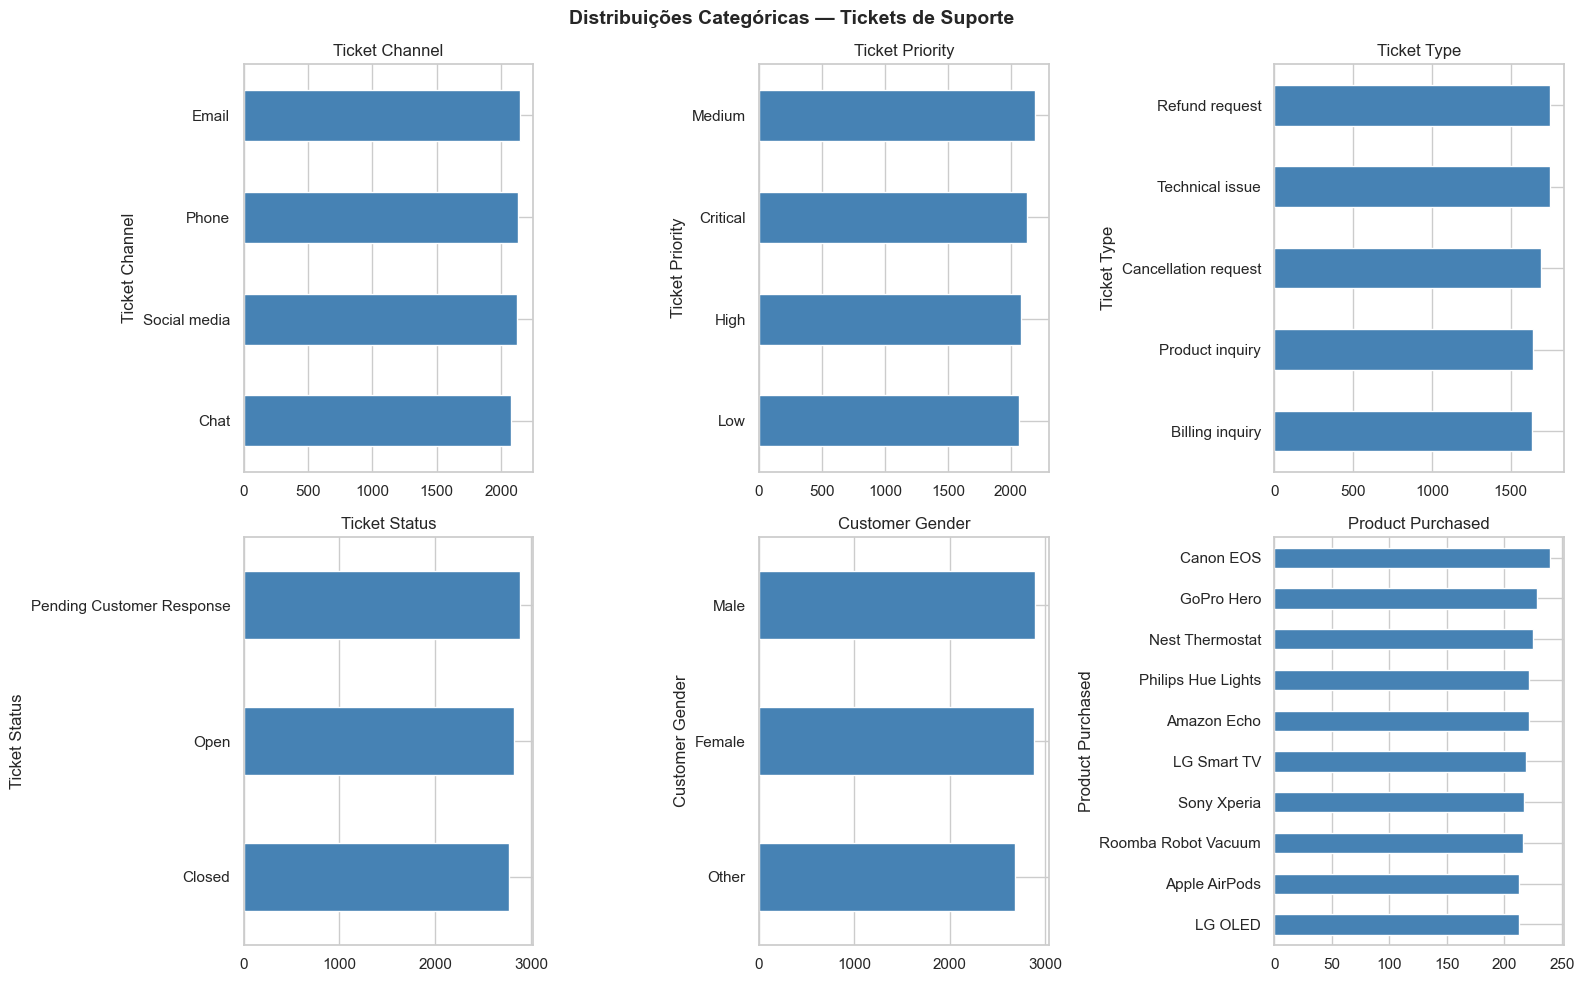

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Distribuições Categóricas — Tickets de Suporte', fontsize=14, fontweight='bold')

for ax, col in zip(axes.flat, cat_cols + ['Product Purchased']):
    counts = df1[col].value_counts()
    if len(counts) > 10:
        counts = counts.head(10)
    counts.plot.barh(ax=ax, color='steelblue')
    ax.set_title(col)
    ax.invert_yaxis()

plt.tight_layout()
plt.show()

## 3. Time Metrics — FRT & TTR

First Response Time and Time to Resolution are the core operational metrics.
These tell us **where time is being lost** — the Director of Operations' main question.

We need to parse the time strings into minutes for analysis.

In [ ]:
# Inspect raw time format
print("FRT samples:")
print(df1['First Response Time'].dropna().head(10).tolist())
print("\nTTR samples:")
print(df1['Time to Resolution'].dropna().head(10).tolist())

In [ ]:
# FRT e TTR são timestamps, não durações como "5 hours"
# Precisamos calcular a diferença entre eles para obter durações
# Primeiro, vamos converter para datetime
df1['frt_dt'] = pd.to_datetime(df1['First Response Time'], errors='coerce')
df1['ttr_dt'] = pd.to_datetime(df1['Time to Resolution'], errors='coerce')

# Calcular duração entre FRT e TTR (se ambos existem)
mask = df1['frt_dt'].notna() & df1['ttr_dt'].notna()
df1.loc[mask, 'resolution_duration_hours'] = (df1.loc[mask, 'ttr_dt'] - df1.loc[mask, 'frt_dt']).dt.total_seconds() / 3600

print(f"FRT parsed: {df1['frt_dt'].notna().sum()}/{len(df1)}")
print(f"TTR parsed: {df1['ttr_dt'].notna().sum()}/{len(df1)}")
print(f"Resolution duration calculada: {df1['resolution_duration_hours'].notna().sum()}")
print()
print("Resolution Duration (hours) — tempo entre primeira resposta e resolução:")
print(df1['resolution_duration_hours'].describe().round(2))

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df1['resolution_duration_hours'].dropna().hist(bins=50, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Duração da Resolução (horas)')
axes[0].set_xlabel('Horas')
med = df1['resolution_duration_hours'].median()
if pd.notna(med):
    axes[0].axvline(med, color='red', linestyle='--', label=f"Mediana: {med:.1f}h")
    axes[0].legend()

# FRT timestamp distribution (hour of day)
df1['frt_hour'] = df1['frt_dt'].dt.hour
df1['frt_hour'].dropna().hist(bins=24, ax=axes[1], color='darkorange', edgecolor='white')
axes[1].set_title('Hora da Primeira Resposta (distribuição)')
axes[1].set_xlabel('Hora do dia')

plt.tight_layout()
plt.show()

## 4. Time by Dimension — Where is time lost?

Cross-tab FRT and TTR by channel, priority, and ticket type to find the worst combinations.

In [ ]:
# Duração média da resolução por canal
for metric, label in [('resolution_duration_hours', 'Duração Resolução (horas)')]:
    print(f"\n--- {label} por Canal ---")
    print(df1.groupby('Ticket Channel')[metric].agg(['mean', 'median', 'std', 'count']).sort_values('mean', ascending=False).round(1))

In [ ]:
# Duração por prioridade e tipo
print("--- Duração Resolução (horas) por Prioridade ---")
print(df1.groupby('Ticket Priority')['resolution_duration_hours'].agg(['mean', 'median', 'count']).sort_values('mean', ascending=False).round(1))

print("\n--- Duração Resolução (horas) por Tipo ---")
print(df1.groupby('Ticket Type')['resolution_duration_hours'].agg(['mean', 'median', 'count']).sort_values('mean', ascending=False).round(1))

In [ ]:
# Heatmap: Duração por Canal × Prioridade
pivot = df1.pivot_table(values='resolution_duration_hours', index='Ticket Channel', columns='Ticket Priority', aggfunc='mean')
fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='YlOrRd', ax=ax)
ax.set_title('Duração Média da Resolução (horas) — Canal × Prioridade')
plt.tight_layout()
plt.show()

In [ ]:
# Heatmap: Duração por Canal × Tipo de Ticket
pivot2 = df1.pivot_table(values='resolution_duration_hours', index='Ticket Channel', columns='Ticket Type', aggfunc='mean')
fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(pivot2, annot=True, fmt='.1f', cmap='YlOrRd', ax=ax)
ax.set_title('Duração Média da Resolução (horas) — Canal × Tipo de Ticket')
plt.tight_layout()
plt.show()

## 5. Customer Satisfaction Analysis

CSAT is the outcome metric. Understanding what correlates with low satisfaction points us to the biggest pain points.

In [ ]:
# CSAT distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df1['Customer Satisfaction Rating'].value_counts().sort_index().plot.bar(ax=axes[0], color='steelblue')
axes[0].set_title('Distribuição CSAT (1-5)')
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Contagem')

# CSAT por canal
df1.groupby('Ticket Channel')['Customer Satisfaction Rating'].mean().sort_values().plot.barh(ax=axes[1], color='darkorange')
axes[1].set_title('CSAT Médio por Canal')
axes[1].set_xlabel('Rating Médio')

plt.tight_layout()
plt.show()

In [ ]:
# Correlação: Duração da resolução vs CSAT
fig, ax = plt.subplots(figsize=(8, 5))

df1.groupby('Customer Satisfaction Rating')['resolution_duration_hours'].mean().plot.bar(ax=ax, color='darkorange')
ax.set_title('Duração Média da Resolução por Rating CSAT')
ax.set_xlabel('CSAT Rating')
ax.set_ylabel('Duração Média (horas)')

plt.tight_layout()
plt.show()

## 6. Product Analysis

Which products generate the most tickets? Which have the worst resolution times?

In [ ]:
# Produto: volume, duração, CSAT
product_stats = df1.groupby('Product Purchased').agg(
    tickets=('Ticket ID', 'count'),
    avg_resolution=('resolution_duration_hours', 'mean'),
    avg_csat=('Customer Satisfaction Rating', 'mean'),
).sort_values('tickets', ascending=False).round(1)
product_stats

## 7. Dataset 2 — IT Service Tickets (Quick Look)

This dataset is simpler (just text + category). We'll use it for classification benchmarking later.

In [14]:
# Dataset 2 já carregado como df2 acima
print(f"Shape: {df2.shape}")
print(f"\n--- Topic Groups ---")
print(df2['Topic_group'].value_counts())
print(f"\n--- Amostras de documentos ---")
for _, row in df2.head(3).iterrows():
    print(f"[{row['Topic_group']}] {row['Document'][:120]}...")

Shape: (47837, 2)

--- Topic Groups ---
Topic_group
Hardware                 13617
HR Support               10915
Access                    7125
Miscellaneous             7060
Storage                   2777
Purchase                  2464
Internal Project          2119
Administrative rights     1760
Name: count, dtype: int64

--- Amostras de documentos ---
[Hardware] connection with icon icon dear please setup icon per icon engineers please let other details needed thanks lead...
[Access] work experience user work experience user hi work experience student coming next his name much appreciate him duration t...
[Hardware] requesting for meeting requesting meeting hi please help follow equipments cable pc cord plug...


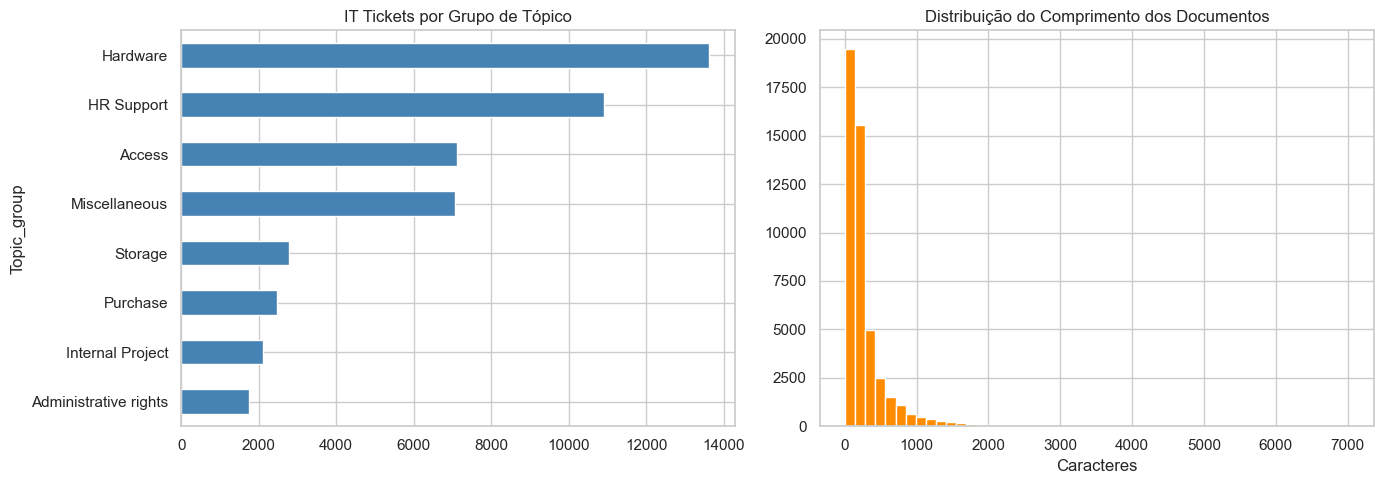

In [15]:
# Distribuição do comprimento dos documentos — Dataset 2
df2['doc_len'] = df2['Document'].str.len()
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df2['Topic_group'].value_counts().plot.barh(ax=axes[0], color='steelblue')
axes[0].set_title('IT Tickets por Grupo de Tópico')
axes[0].invert_yaxis()

df2['doc_len'].hist(bins=50, ax=axes[1], color='darkorange', edgecolor='white')
axes[1].set_title('Distribuição do Comprimento dos Documentos')
axes[1].set_xlabel('Caracteres')

plt.tight_layout()
plt.show()

## 8. Key Findings

_Populated after execution — observations, data quality issues, and initial hypotheses._